<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/BOA012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

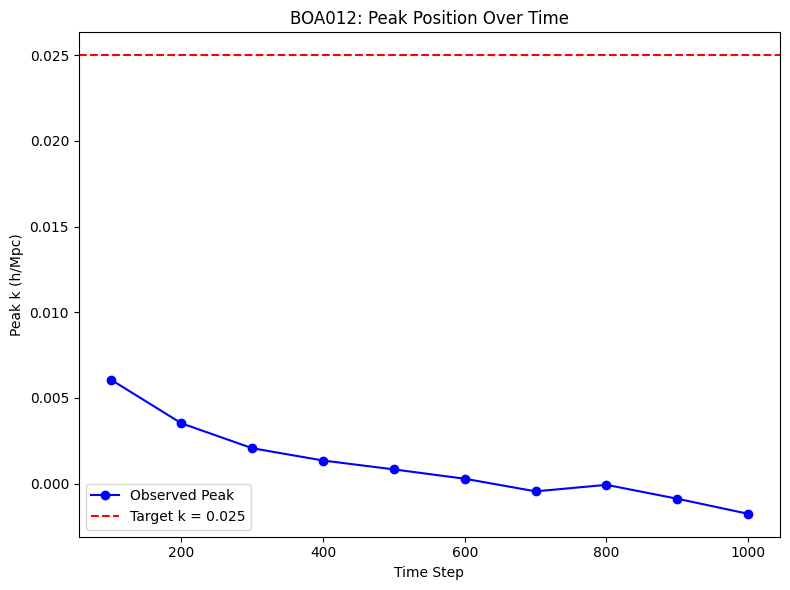

In [1]:
# BOA012: Temporal drift test for HES ruler
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit

# Parameters
N = 256
dt = 0.01
steps = 1000
snapshot_interval = 100
kappa = 0.1
delta = 0.05
epsilon = 0.005
gamma_0 = 0.25
xi_std = 0.02
scale_factor = 0.0067 / 0.139  # from BOA007
target_k = 0.025  # h/Mpc

# Gaussian fit function
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Initialize field
A = np.random.normal(0, 0.1, (N, N))
peak_positions = []
time_points = []

# Evolve and sample
for t in range(steps):
    xi = np.random.normal(0, xi_std, (N, N))
    laplacian = (
        np.roll(A, 1, 0) + np.roll(A, -1, 0) +
        np.roll(A, 1, 1) + np.roll(A, -1, 1) - 4 * A
    )
    dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0 * laplacian + xi) * dt
    A += np.nan_to_num(dA)

    if (t + 1) % snapshot_interval == 0:
        fft_A = fftshift(fft2(A))
        power_spectrum = np.abs(fft_A)**2
        y, x = np.indices((N, N))
        center = (N // 2, N // 2)
        r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
        r = r.astype(np.int32)
        tbin = np.bincount(r.ravel(), power_spectrum.ravel())
        nr = np.bincount(r.ravel())
        radial_ps = tbin / (nr + 1e-10)
        k_vals = np.arange(len(radial_ps)) / (N / 2)
        radial_ps_smooth = gaussian_filter(radial_ps, sigma=2)

        fit_mask = (k_vals > 0.15) & (k_vals < 0.35)
        k_fit = k_vals[fit_mask]
        ps_fit = radial_ps_smooth[fit_mask]
        try:
            popt, _ = curve_fit(gaussian, k_fit, ps_fit, p0=[np.max(ps_fit), 0.25, 0.05])
            _, k0_lattice, _ = popt
            k0_physical = k0_lattice * scale_factor
            peak_positions.append(k0_physical)
            time_points.append(t + 1)
        except:
            peak_positions.append(np.nan)
            time_points.append(t + 1)

# Plot peak position over time
plt.figure(figsize=(8, 6))
plt.plot(time_points, peak_positions, marker='o', linestyle='-', color='blue', label='Observed Peak')
plt.axhline(target_k, color='red', linestyle='--', label=f'Target k = {target_k:.3f}')
plt.title("BOA012: Peak Position Over Time")
plt.xlabel("Time Step")
plt.ylabel("Peak k (h/Mpc)")
plt.legend()
plt.tight_layout()
plt.show()
